In [4]:
from sklearn.datasets import fetch_california_housing

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
df = fetch_california_housing()

In [8]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [9]:
#  convert this data into dataframe pandas

In [10]:
type(df)

sklearn.utils._bunch.Bunch

In [14]:
df1  =pd.DataFrame(df.data)
df1.columns = df.feature_names #  label the columns
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [17]:
# the price of housees is in the target in millions of USD
df1['Prices']=(df.target)
df1.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Prices
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
#  Dividing the dataset into independant anddependant features
X=df1.iloc[:,:-1] # skiplast target
y = df1.iloc[:,-1] # target depeandant

In [20]:
y

,Prices
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


**Cross-validation** in scikit-learn (sklearn) is a technique used to evaluate how well a machine learning model will perform on unseen data by splitting the dataset into multiple parts (called folds). The model is trained on some folds and tested on the remaining fold, and this process is repeated so that each fold is used for testing once. The performance scores from all iterations are then averaged to provide a more reliable estimate of the model's generalization ability than a single train-test split. In sklearn, this is commonly done using functions like cross_val_score() and methods such as K-Fold Cross-Validation.
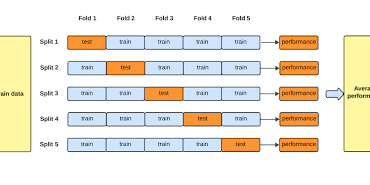

In [24]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

llr = LinearRegression()

mse = cross_validate(llr,X,y,scoring='neg_mean_squared_error',cv=5)
print(mse)

{'fit_time': array([0.0151763 , 0.01235271, 0.01413059, 0.02157402, 0.02587605]), 'score_time': array([0.00311422, 0.00285554, 0.00963402, 0.01302171, 0.01104283]), 'test_score': array([-0.48485857, -0.62249739, -0.64621047, -0.5431996 , -0.49468484])}


In [29]:

# we are doing five splits and have five mse values so take mean of all
print(np.mean(mse['test_score']))

{'fit_time': array([0.0151763 , 0.01235271, 0.01413059, 0.02157402, 0.02587605]), 'score_time': array([0.00311422, 0.00285554, 0.00963402, 0.01302171, 0.01104283]), 'test_score': array([-0.48485857, -0.62249739, -0.64621047, -0.5431996 , -0.49468484])}
-0.5582901717686546


In GridSearchCV, the scoring system assumes that higher scores are better. However, Mean Squared Error (MSE) is a loss metric where lower values are better (0 is perfect).

To make MSE compatible with GridSearchCV's "maximize score" approach, scikit-learn provides neg_mean_squared_error, which is simply:

**neg_MSE**=**−MSE**

For example:
Model A: MSE = 25 → neg_MSE = -25
Model B: MSE = 10 → neg_MSE = -10
 **bold text**

Since -10 > -25, GridSearchCV correctly chooses Model B (the one with the lower MSE).

In [33]:
# Ridgwe Regression
from sklearn.linear_model import Ridge,Lasso
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
params = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
# chooonse among the alphs the best for Alpha|slope}^2
ridge_regressor = GridSearchCV(ridge,params,scoring='neg_mean_squared_error',cv=5)

In [34]:
ridge_regressor.fit(X,y)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]})

In [39]:
print(ridge_regressor.best_params_)
print(f"Best neg_mean_squared_error: {ridge_regressor.best_score_}")

# To get the actual MSE for comparison, we would take the absolute value
# or multiply by -1 if the best_score_ is indeed the neg_mean_squared_error
# print(f"Corresponding MSE: {-ridge_regressor.best_score_}")

{'alpha': 100}
Best neg_mean_squared_error: 0.5534066789698884


## Trying with a Different Dataset: Boston Housing

In [45]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_657/3437137265.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [46]:
df_boston = pd.DataFrame(data, columns=feature_names)
df_boston['Price'] = target
display(df_boston.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Splitting Features and Target for Boston Housing

In [47]:
X_boston = df_boston.iloc[:, :-1]
y_boston = df_boston.iloc[:, -1]

### Linear Regression on Boston Housing

In [48]:
llr_boston = LinearRegression()
mse_boston_lr = cross_validate(llr_boston, X_boston, y_boston, scoring='neg_mean_squared_error', cv=5)
print(f"Mean MSE for Linear Regression (Boston): {-np.mean(mse_boston_lr['test_score'])}")

Mean MSE for Linear Regression (Boston): 37.13180746769887


### Ridge Regression on Boston Housing

In [50]:
ridge_boston = Ridge()
params_boston = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100]}
ridge_regressor_boston = GridSearchCV(ridge_boston, params_boston, scoring='neg_mean_squared_error', cv=5)
ridge_regressor_boston.fit(X_boston, y_boston)
print(f"Best Ridge Alpha: {ridge_regressor_boston.best_params_}")
print(f"Best Ridge MSE: {ridge_regressor_boston.best_score_}")

Best Ridge Alpha: {'alpha': 100}
Best Ridge MSE: -29.905701947540297


In [53]:
# Ridgwe Regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso = Lasso()
params = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
# chooonse among the alphs the best for Alpha|slope}^2
lasso_regressor = GridSearchCV(lasso,params,scoring='neg_mean_squared_error',cv=5)

In [65]:

lasso_r = cross_validate(lasso, X_boston, y_boston, scoring='neg_mean_squared_error', cv=5)
print(f"Mean MSE for Lasso Regression (Boston): {np.mean(lasso_r['test_score'])}")

Mean MSE for Lasso Regression (Boston): -35.53158022069486


In [58]:
lasso_regressor.fit(X_boston,y_boston)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.633e+03, tolerance: 3.919e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.760e+03, tolerance: 3.307e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.210e+03, tolerance: 2.814e

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [68]:
print(lasso_regressor.best_params_)
print(f"Best neg_mean_squared_error Lasso : {lasso_regressor.best_score_}")
print(ridge_regressor_boston.best_params_)
print(f"Best neg_mean_squared_error Lasso : {ridge_regressor_boston.best_score_}")


{'alpha': 1}
Best neg_mean_squared_error Lasso : -35.53158022069486
{'alpha': 100}
Best neg_mean_squared_error Lasso : -29.905701947540297


In [72]:
# Fix: split the Boston dataset instead of the California one
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
X_train, X_test, y_train, y_test = train_test_split(X_boston, y_boston, test_size=0.3, random_state=101)

In [73]:
# Now this will work as the features match
prediction = lasso_regressor.predict(X_test)
print(f"First 5 predictions: {prediction[:5]}")
print(f"R2 Score: {r2_score(y_test, prediction)}")

First 5 predictions: [37.11837381 28.03248999 17.46085551 17.9368786  31.55393156]
R2 Score: 0.6592838796702563


In [76]:
ridge_preds = ridge_regressor_boston.predict(X_boston)
print(f"First 5 predictions: {ridge_preds[:5]}")
print(f"R2 Score: {r2_score(y_boston, ridge_preds)}")

First 5 predictions: [31.17124533 24.95003631 30.05033086 29.21616521 28.01253616]
R2 Score: 0.717864397707179


In [77]:
from sklearn.metrics import r2_score

# 1. Lasso Predictions and R2
lasso_test_preds = lasso_regressor.predict(X_test)
lasso_r2 = r2_score(y_test, lasso_test_preds)

# 2. Ridge Predictions and R2
ridge_test_preds = ridge_regressor_boston.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_test_preds)

print(f"Comparison of R2 Scores on Test Set:")
print(f"------------------------------------")
print(f"Lasso R2 Score: {lasso_r2:.4f}")
print(f"Ridge R2 Score: {ridge_r2:.4f}")

if ridge_r2 > lasso_r2:
    print('\nResult: Ridge Regression performed better.')
else:
    print('\nResult: Lasso Regression performed better.')

Comparison of R2 Scores on Test Set:
------------------------------------
Lasso R2 Score: 0.6593
Ridge R2 Score: 0.7064

Result: Ridge Regression performed better.


**perform Logistic Regresssion in load cancer dataet**

## Logistic Regression on Breast Cancer Dataset

In [78]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data
cancer_data = load_breast_cancer()
df_cancer = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df_cancer['target'] = cancer_data.target

display(df_cancer.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [81]:
# Split features and target
X_c = df_cancer.iloc[:, :-1]
y_c = df_cancer.iloc[:, -1]

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.3, random_state=101)

# Initialize and fit Logistic Regression
log_reg = LogisticRegression(max_iter=5000)
parameter = {'C': [0.1, 1, 10, 20, 50]}

log_regressor = GridSearchCV(log_reg, parameter, scoring='f1', cv=5)
log_regressor.fit(X_train_c, y_train_c)

print(f"Best Parameters: {log_regressor.best_params_}")
print(f"Best Accuracy Score: {log_regressor.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Parameters: {'C': 50}
Best Accuracy Score: 0.9762587860222791


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [80]:
# Predictions and Evaluation
y_pred_c = log_regressor.predict(X_test_c)

print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))
print(f"Final Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")

Confusion Matrix:
[[ 60   6]
 [  1 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        66
           1       0.95      0.99      0.97       105

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

Final Accuracy: 0.9591
